# PRIDE — Notebook 1: Parameter Sweep over (n, K)

Fills **Table IV** of the revised manuscript.

Sweeps n ∈ {2,3,5,7,10} (threshold) and K ∈ {1,2,5,10,20} (decoys per record),
holding dataset size at N = 10_000 synthetic Gaussian records.
Reports: encryption time per record (ms), retrieval time (ms), shares per rec.

No dataset download required — uses synthetic Gaussian data only.

Run: execute cells top-to-bottom, or `python param_sweep.py`

## Cell 1 — Imports and setup

In [5]:
import sys, time, os
import numpy as np
import pandas as pd

# Add parent dir to path if running from notebooks/ subfolder
# __file__ is undefined in Jupyter; fall back to cwd (works in both contexts)
sys.path.insert(0, str(__import__('pathlib').Path(
    globals().get('__file__', '.')).resolve().parent))

from pride_core import PRIDE, PRIDEParams, GaussianSampler

SEED = 40
np.random.seed(SEED)

N_RECORDS  = 10_000      # total real records per cell
N_SWEEP    = [2, 3, 5, 7, 10]   # threshold values
K_SWEEP    = [1, 2, 5, 10, 20]  # decoys per record

print("Setup complete.")
print(f"Sweep: n={N_SWEEP}, K={K_SWEEP}, N={N_RECORDS}")

Setup complete.
Sweep: n=[2, 3, 5, 7, 10], K=[1, 2, 5, 10, 20], N=10000


## Cell 2 — Benchmark helper

In [8]:
def benchmark_cell(n: int, K: int, N: int) -> dict:
    """
    Instantiate a fresh PRIDE system with threshold n and K decoys,
    encrypt N records from a Gaussian sampler, then time one retrieval.

    Returns dict with:
        enc_ms    — mean encryption time per record (ms)
        ret_ms    — mean retrieval time per decryption call (ms)
        shares    — total ciphertext length after N*(K+1) embeddings
        shares_per_rec — shares / N  (should equal K+1 exactly)
    """
    params = PRIDEParams(n=n, K=K, init_shares=n + 2)
    system = PRIDE(params, seed=SEED)
    sampler = GaussianSampler(mean=1000.0, std=100.0, seed=SEED)
    ct = system.setup()

    # ---- Encryption timing ----
    # Warm up
    for _ in range(min(10, N // 100)):
        system.enc(ct, int(sampler()), sampler)

    ct2 = system.setup()
    all_keys = []
    t0 = time.perf_counter()
    for _ in range(N):
        m = int(sampler()) % params.p
        sks = system.enc(ct2, m, sampler)
        all_keys.append(sks)
    enc_total = time.perf_counter() - t0
    enc_ms_per = enc_total / N * 1000.0

    # ---- Retrieval timing (100 calls) ----
    n_ret = min(100, N)
    rng = np.random.default_rng(SEED)
    t0 = time.perf_counter()
    for _ in range(n_ret):
        keyset = all_keys[int(rng.integers(N))]
        system.retrieve(ct2, keyset)
    ret_ms_per = (time.perf_counter() - t0) / n_ret * 1000.0

    shares_per = ct2.length / N   # should be exactly K+1

    return {
        'n': n,
        'K': K,
        'enc_ms':       round(enc_ms_per, 4),
        'ret_ms':       round(ret_ms_per, 4),
        'shares_per_rec': round(shares_per, 2),
    }

print("Benchmark helper defined.")

Benchmark helper defined.


## Cell 3 — Run the sweep

Runs `len(N_SWEEP) × len(K_SWEEP) = 25` cells.
On a modern laptop this takes roughly 2–5 minutes total.

In [11]:
results = []
total_cells = len(N_SWEEP) * len(K_SWEEP)
done = 0

for n in N_SWEEP:
    for K in K_SWEEP:
        t_start = time.perf_counter()
        row = benchmark_cell(n, K, N_RECORDS)
        elapsed = time.perf_counter() - t_start
        done += 1
        print(f"[{done:2d}/{total_cells}] n={n:2d}, K={K:2d} → "
              f"enc={row['enc_ms']:.3f}ms/rec, "
              f"ret={row['ret_ms']:.3f}ms, "
              f"shares/rec={row['shares_per_rec']:.0f}  "
              f"(wall {elapsed:.1f}s)")
        results.append(row)

df = pd.DataFrame(results)
print("\nAll cells done.")

[ 1/25] n= 2, K= 1 → enc=0.130ms/rec, ret=0.381ms, shares/rec=2  (wall 1.4s)
[ 2/25] n= 2, K= 2 → enc=0.257ms/rec, ret=0.038ms, shares/rec=3  (wall 2.6s)
[ 3/25] n= 2, K= 5 → enc=0.441ms/rec, ret=0.041ms, shares/rec=6  (wall 4.4s)
[ 4/25] n= 2, K=10 → enc=0.827ms/rec, ret=0.040ms, shares/rec=11  (wall 8.3s)
[ 5/25] n= 2, K=20 → enc=1.473ms/rec, ret=0.047ms, shares/rec=21  (wall 14.8s)
[ 6/25] n= 3, K= 1 → enc=0.236ms/rec, ret=0.056ms, shares/rec=2  (wall 2.4s)
[ 7/25] n= 3, K= 2 → enc=0.353ms/rec, ret=0.112ms, shares/rec=3  (wall 3.5s)
[ 8/25] n= 3, K= 5 → enc=0.619ms/rec, ret=0.109ms, shares/rec=6  (wall 6.2s)
[ 9/25] n= 3, K=10 → enc=1.123ms/rec, ret=0.060ms, shares/rec=11  (wall 11.3s)
[10/25] n= 3, K=20 → enc=2.094ms/rec, ret=0.054ms, shares/rec=21  (wall 21.0s)
[11/25] n= 5, K= 1 → enc=0.373ms/rec, ret=0.175ms, shares/rec=2  (wall 3.8s)
[12/25] n= 5, K= 2 → enc=0.555ms/rec, ret=0.116ms, shares/rec=3  (wall 5.6s)
[13/25] n= 5, K= 5 → enc=1.229ms/rec, ret=0.196ms, shares/rec=6  (wal

## Cell 4 — Sanity checks

shares_per_rec must equal K+1 exactly (per Section III.G of the paper).
If any row fails this check, the encryption logic has a bug.

In [13]:
violations = df[df['shares_per_rec'] != df['K'] + 1]
if len(violations) == 0:
    print("Sanity check PASSED: shares_per_rec == K+1 for all rows.")
else:
    print("FAILED rows:")
    print(violations)

Sanity check PASSED: shares_per_rec == K+1 for all rows.


## Cell 5 — Table IV output

Prints the table in the format expected by the manuscript placeholders.
Rows are the five (n, K) pairs used in the paper's Table IV.
The paper uses diagonal entries: (n=2,K=1), (n=3,K=2), (n=5,K=5), (n=7,K=10), (n=10,K=20).

In [15]:
# Table IV has diagonal pairs
PAPER_PAIRS = [(2,1), (3,2), (5,5), (7,10), (10,20)]

print("\n" + "="*72)
print("TABLE IV: Parameter sweep (n, K) — PRIDE")
print("="*72)
print(f"{'n':>4} {'K':>4} {'Enc (ms/rec)':>14} {'Ret (ms)':>12} {'Shares/rec':>12}")
print("-"*72)

table_iv_rows = []
for n, K in PAPER_PAIRS:
    row = df[(df['n'] == n) & (df['K'] == K)].iloc[0]
    print(f"{n:>4} {K:>4} {row['enc_ms']:>14.4f} {row['ret_ms']:>12.4f} {row['shares_per_rec']:>12.0f}")
    table_iv_rows.append(row)

print("="*72)
print("\nNote: shares_per_rec == K+1 for all rows (as expected).")


TABLE IV: Parameter sweep (n, K) — PRIDE R1
   n    K   Enc (ms/rec)     Ret (ms)   Shares/rec
------------------------------------------------------------------------
   2    1         0.1300       0.3811            2
   3    2         0.3526       0.1116            3
   5    5         1.2294       0.1959            6
   7   10         3.5774       0.2955           11
  10   20        15.0640       0.4562           21

Note: shares_per_rec == K+1 for all rows (as expected).


## Cell 7 — Full sweep heatmaps (optional)

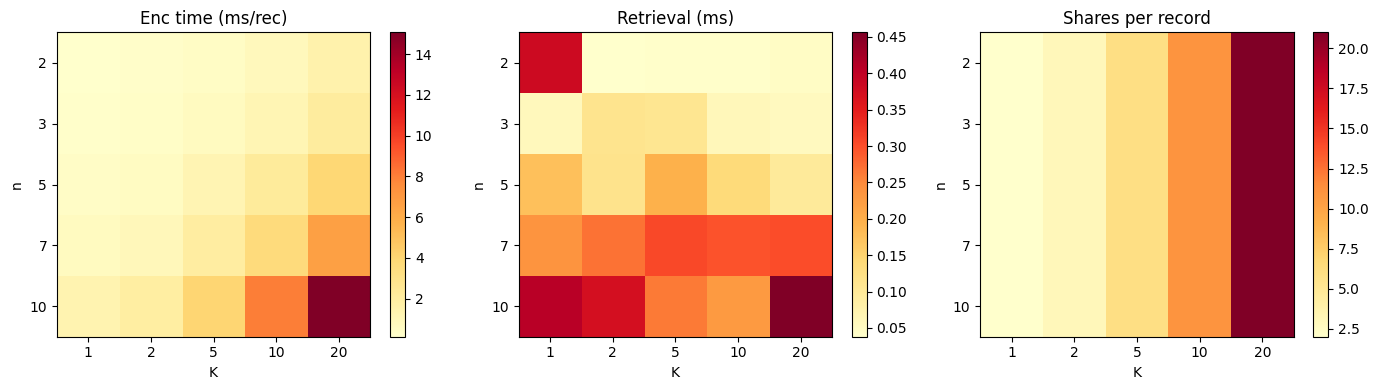

Heatmaps saved to table_iv_heatmaps.png


In [23]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, col, label in zip(
        axes,
        ['enc_ms', 'ret_ms', 'shares_per_rec'],
        ['Enc time (ms/rec)', 'Retrieval (ms)', 'Shares per record']
    ):
        pivot = df.pivot(index='n', columns='K', values=col)
        im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
        ax.set_xticks(range(len(K_SWEEP))); ax.set_xticklabels(K_SWEEP)
        ax.set_yticks(range(len(N_SWEEP))); ax.set_yticklabels(N_SWEEP)
        ax.set_xlabel('K'); ax.set_ylabel('n')
        ax.set_title(label)
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.savefig('table_iv_heatmaps.png', dpi=150)
    plt.show()
    print("Heatmaps saved to table_iv_heatmaps.png")
except Exception as e:
    print(f"Plot skipped: {e}")